In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for all charts
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Load SQL results
sql_path = r'C:\Users\sunka\Documents\victoria-road-crash-analysis\sql'

yearly    = pd.read_csv(sql_path + r'\query1_yearly_trend.csv')
hourly    = pd.read_csv(sql_path + r'\query2_hourly_fatalities.csv')
age_sex   = pd.read_csv(sql_path + r'\query3_age_sex_fatalities.csv')
speed     = pd.read_csv(sql_path + r'\query4_speed_zone_fatal_rate.csv')
day_week  = pd.read_csv(sql_path + r'\query5_day_of_week.csv')

print("✅ All data loaded!")
print(f"Yearly data: {len(yearly)} years")
print(f"Hourly data: {len(hourly)} hours")
print(f"Age/sex data: {len(age_sex)} groups")
print(f"Speed zones: {len(speed)} zones")
print(f"Day of week: {len(day_week)} days")

✅ All data loaded!
Yearly data: 14 years
Hourly data: 10 hours
Age/sex data: 15 groups
Speed zones: 10 zones
Day of week: 8 days


In [3]:
mkdir assets

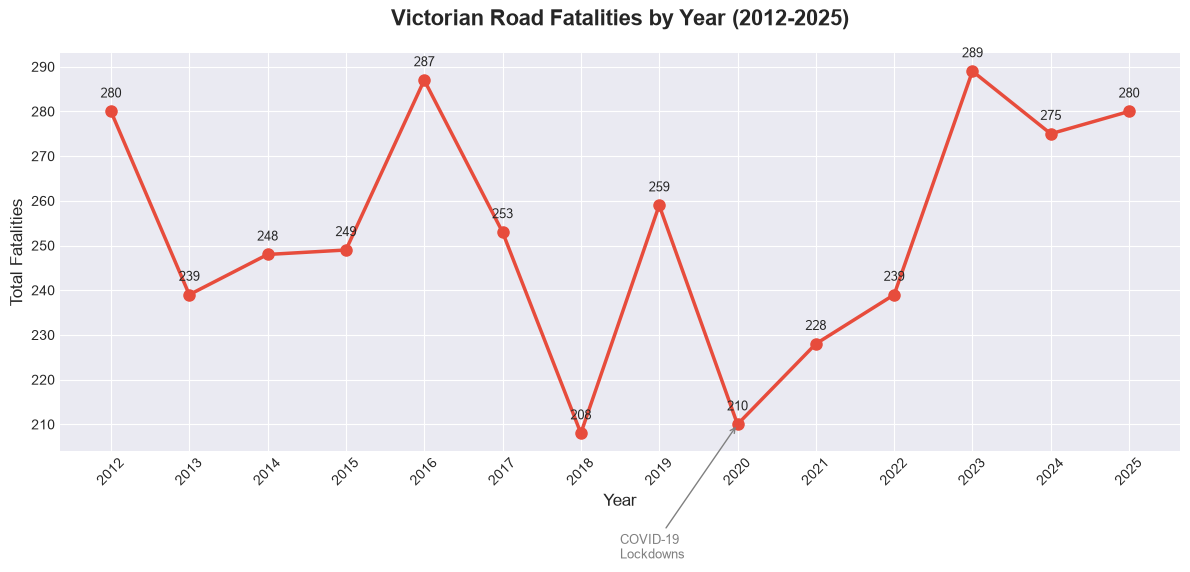

✅ Chart 1 saved!


In [4]:
# CHART 1: Fatalities by year - is Victoria getting safer?
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(yearly['YEAR'], yearly['total_fatalities'], 
        color='#E74C3C', linewidth=2.5, marker='o', markersize=8)

# Add value labels on each point
for x, y in zip(yearly['YEAR'], yearly['total_fatalities']):
    ax.annotate(str(y), (x, y), textcoords="offset points", 
                xytext=(0, 10), ha='center', fontsize=9)

ax.set_title('Victorian Road Fatalities by Year (2012-2025)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Total Fatalities', fontsize=12)
ax.set_xticks(yearly['YEAR'])
plt.xticks(rotation=45)

# Add COVID annotation
ax.annotate('COVID-19\nLockdowns', xy=(2020, 210), 
            xytext=(2018.5, 180),
            arrowprops=dict(arrowstyle='->', color='gray'),
            fontsize=9, color='gray')

plt.tight_layout()
plt.savefig(r'C:\Users\sunka\Documents\victoria-road-crash-analysis\assets\chart1_yearly_trend.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 1 saved!")

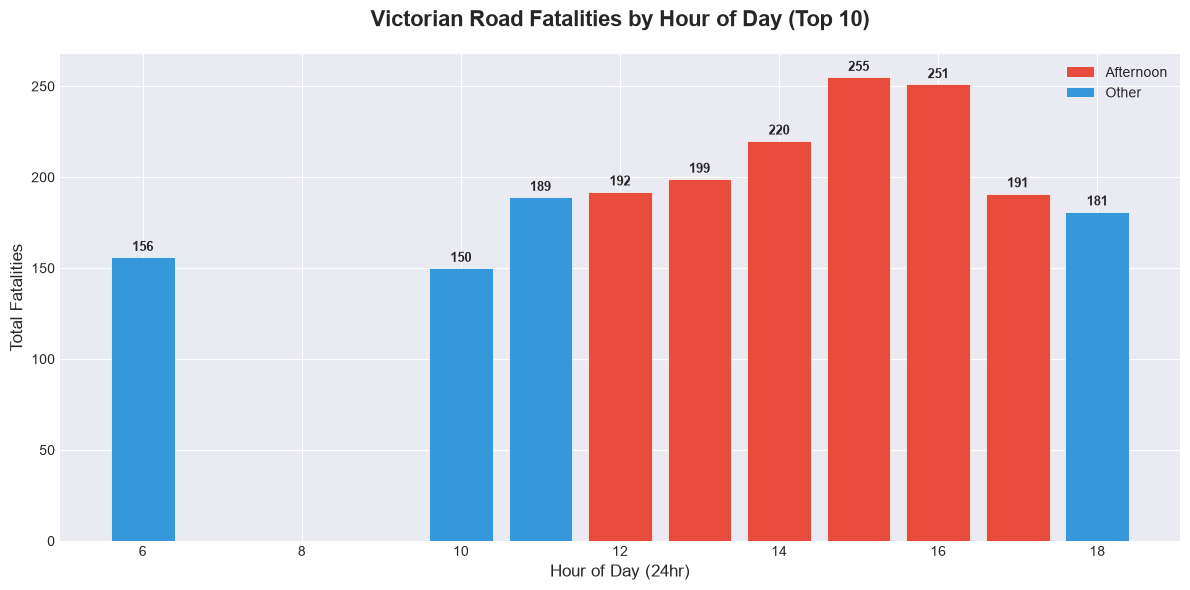

✅ Chart 2 saved!


In [5]:
# CHART 2: Which hours are deadliest?
fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#E74C3C' if t == 'Afternoon' else '#3498DB' 
          for t in hourly['time_period']]

bars = ax.bar(hourly['hour_of_day'], hourly['fatalities'], 
              color=colors, edgecolor='white', linewidth=0.5)

# Add value labels on bars
for bar, val in zip(bars, hourly['fatalities']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            str(val), ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title('Victorian Road Fatalities by Hour of Day (Top 10)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Hour of Day (24hr)', fontsize=12)
ax.set_ylabel('Total Fatalities', fontsize=12)

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#E74C3C', label='Afternoon'),
                   Patch(facecolor='#3498DB', label='Other')]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.savefig(r'C:\Users\sunka\Documents\victoria-road-crash-analysis\assets\chart2_hourly.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 2 saved!")

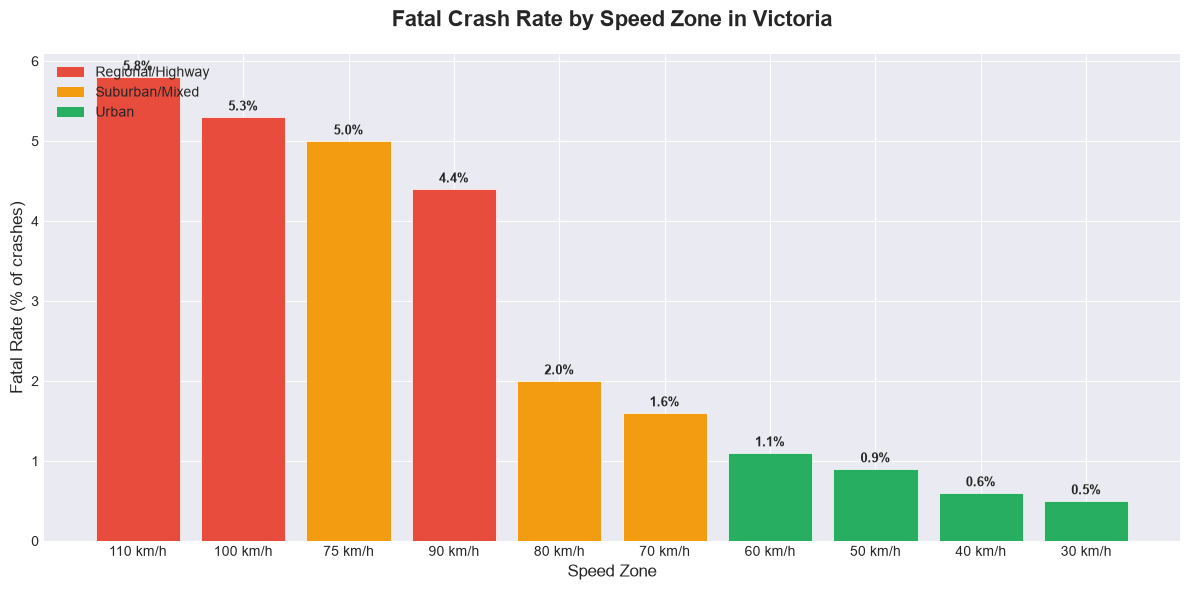

✅ Chart 3 saved!


In [6]:
# CHART 3: Fatal rate by speed zone
fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#E74C3C' if r == 'Regional/Highway' 
          else '#F39C12' if r == 'Suburban/Mixed' 
          else '#27AE60' 
          for r in speed['road_type']]

bars = ax.bar(speed['SPEED_ZONE'].astype(str) + ' km/h', 
              speed['FATAL_RATE_PCT'],
              color=colors, edgecolor='white', linewidth=0.5)

# Add value labels
for bar, val in zip(bars, speed['FATAL_RATE_PCT']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val}%', ha='center', va='bottom', 
            fontsize=9, fontweight='bold')

ax.set_title('Fatal Crash Rate by Speed Zone in Victoria', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Speed Zone', fontsize=12)
ax.set_ylabel('Fatal Rate (% of crashes)', fontsize=12)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#E74C3C', label='Regional/Highway'),
    Patch(facecolor='#F39C12', label='Suburban/Mixed'),
    Patch(facecolor='#27AE60', label='Urban')
]
ax.legend(handles=legend_elements, loc='upper left')

plt.tight_layout()
plt.savefig(r'C:\Users\sunka\Documents\victoria-road-crash-analysis\assets\chart3_speed_zones.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 3 saved!")

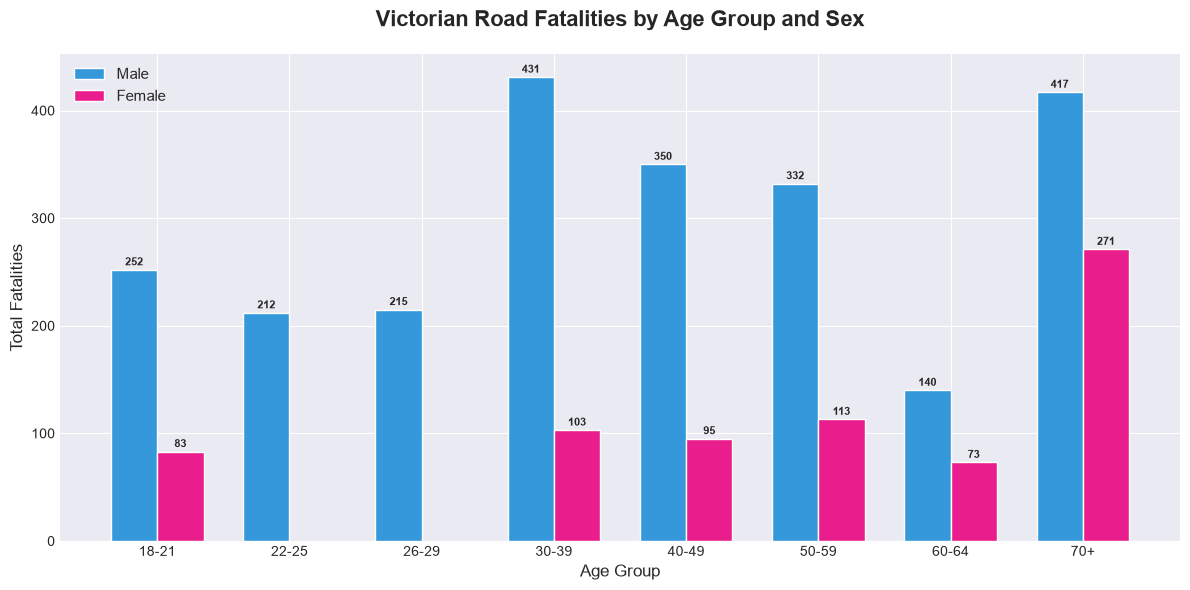

✅ Chart 4 saved!


In [5]:
# CHART 4: Who is dying - age group and sex (FIXED)
fig, ax = plt.subplots(figsize=(12, 6))

# Separate male and female
males   = age_sex[age_sex['SEX'] == 'M'].copy()
females = age_sex[age_sex['SEX'] == 'F'].copy()

# Sort by age group
age_order = ['18-21','22-25','26-29','30-39',
             '40-49','50-59','60-64','70+']

males   = males[males['AGE_GROUP'].isin(age_order)].set_index('AGE_GROUP').reindex(age_order)
females = females[females['AGE_GROUP'].isin(age_order)].set_index('AGE_GROUP').reindex(age_order)

x = range(len(age_order))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], males['fatalities'],
               width, label='Male', color='#3498DB', edgecolor='white')
bars2 = ax.bar([i + width/2 for i in x], females['fatalities'],
               width, label='Female', color='#E91E8C', edgecolor='white')

# Add value labels
for bar in bars1:
    if bar.get_height() > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                str(int(bar.get_height())), ha='center', 
                va='bottom', fontsize=8, fontweight='bold')
for bar in bars2:
    if bar.get_height() > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                str(int(bar.get_height())), ha='center', 
                va='bottom', fontsize=8, fontweight='bold')

ax.set_title('Victorian Road Fatalities by Age Group and Sex', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Age Group', fontsize=12)
ax.set_ylabel('Total Fatalities', fontsize=12)
ax.set_xticks(list(x))
ax.set_xticklabels(age_order)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig(r'C:\Users\sunka\Documents\victoria-road-crash-analysis\assets\chart4_age_sex.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 4 saved!")

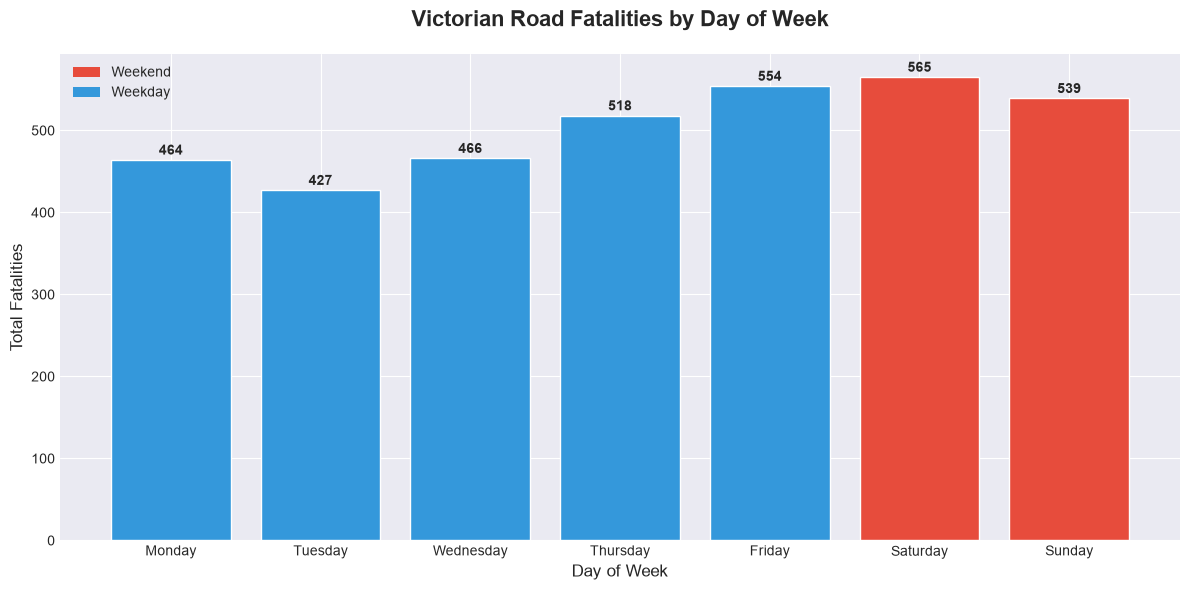

✅ Chart 5 saved!


In [ ]:
# CHART 5: Fatalities by day of week
day_week_clean = day_week.dropna(subset=['DAY_OF_WEEK'])

days_order = ['Monday','Tuesday','Wednesday',
              'Thursday','Friday','Saturday','Sunday']
day_week_clean = day_week_clean[
    day_week_clean['DAY_OF_WEEK'].isin(days_order)]
day_week_clean = day_week_clean.set_index(
    'DAY_OF_WEEK').reindex(days_order).reset_index()

colors = ['#E74C3C' if d in ['Saturday','Sunday'] 
          else '#3498DB' for d in days_order]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(day_week_clean['DAY_OF_WEEK'], 
              day_week_clean['fatalities'],
              color=colors, edgecolor='white')

for bar, val in zip(bars, day_week_clean['fatalities']):
    ax.text(bar.get_x() + bar.get_width()/2, 
            bar.get_height() + 3,
            str(int(val)), ha='center', 
            va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Victorian Road Fatalities by Day of Week',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Day of Week', fontsize=12)
ax.set_ylabel('Total Fatalities', fontsize=12)



from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#E74C3C', label='Weekend'),
    Patch(facecolor='#3498DB', label='Weekday')
]
ax.legend(handles=legend_elements)

plt.tight_layout()
plt.savefig(r'C:\Users\sunka\Documents\victoria-road-crash-analysis\assets\chart5_day_of_week.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 5 saved!")